## Import Libraries

In [434]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Pandas - used for the data loading and cleaning process

Numpy = used for the array implementation

Seaborn - used for the histplot, scatter plot, and barchart

Matplotlib - used for the diagrams 

## Data Ingestion

In [435]:
df = pd.read_csv("Most_Streamed_Spotify_Songs_2024.csv", encoding="latin-1", header=0)
print(df.shape)
print(df)

(4600, 29)
                                Track                        Album Name  \
0                 MILLION DOLLAR BABY      Million Dollar Baby - Single   
1                         Not Like Us                       Not Like Us   
2          i like the way you kiss me        I like the way you kiss me   
3                             Flowers                  Flowers - Single   
4                             Houdini                           Houdini   
...                               ...                               ...   
4595                For the Last Time                 For the Last Time   
4596                 Dil Meri Na Sune  Dil Meri Na Sune (From "Genius")   
4597            Grace (feat. 42 Dugg)                           My Turn   
4598              Nashe Si Chadh Gayi             November Top 10 Songs   
4599  Me Acostumbre (feat. Bad Bunny)   Me Acostumbre (feat. Bad Bunny)   

              Artist Release Date          ISRC All Time Rank  Track Score  \
0      Tom

## Data Cleaning

### 1. Check Null Values

In [436]:
df.isnull().sum()

Track                            0
Album Name                       0
Artist                           5
Release Date                     0
ISRC                             0
All Time Rank                    0
Track Score                      0
Spotify Streams                113
Spotify Playlist Count          70
Spotify Playlist Reach          72
Spotify Popularity             804
YouTube Views                  308
YouTube Likes                  315
TikTok Posts                  1173
TikTok Likes                   980
TikTok Views                   981
YouTube Playlist Reach        1009
Apple Music Playlist Count     561
AirPlay Spins                  498
SiriusXM Spins                2123
Deezer Playlist Count          921
Deezer Playlist Reach          928
Amazon Playlist Count         1055
Pandora Streams               1106
Pandora Track Stations        1268
Soundcloud Streams            3333
Shazam Counts                  577
TIDAL Popularity              4600
Explicit Track      

### 2. Create a list for the deleted columns

In [437]:
deleted_col = ["YouTube Views", "YouTube Likes", "TikTok Posts", "TikTok Likes", "TikTok Views", "YouTube Playlist Reach","Apple Music Playlist Count", "AirPlay Spins",
    "SiriusXM Spins", "Deezer Playlist Count", "Deezer Playlist Reach", "Amazon Playlist Count", "Pandora Streams", "Pandora Track Stations","Soundcloud Streams",
    "Shazam Counts", "TIDAL Popularity","Explicit Track"]

col = ["Artist", "Track", "Album Name", "ISRC", "Release Date", "Spotify Streams", "Spotify Playlist Count", "Spotify Playlist Reach", "Spotify Popularity", "All Time Rank", "Track Score"]

### 3. Drop Null Values and Irrelevant Columns

In [438]:
df = df.dropna(subset=["Artist","Track"])
df = df.drop_duplicates("Track")
df = df.drop(columns=deleted_col, errors = "ignore")

In [439]:
print(df.shape)
df.isnull().sum()

(4365, 11)


Track                       0
Album Name                  0
Artist                      0
Release Date                0
ISRC                        0
All Time Rank               0
Track Score                 0
Spotify Streams            95
Spotify Playlist Count     48
Spotify Playlist Reach     49
Spotify Popularity        715
dtype: int64

### 4. Check Data Types

In [440]:
print(df.dtypes)

Track                         str
Album Name                    str
Artist                        str
Release Date                  str
ISRC                          str
All Time Rank                 str
Track Score               float64
Spotify Streams               str
Spotify Playlist Count        str
Spotify Playlist Reach        str
Spotify Popularity        float64
dtype: object


### 5. Normalise lettering in the dataset

In [441]:
df["Track"] = df["Track"].str.lower()
df["Artist"] = df["Artist"].str.lower()
df["Album Name"] = df["Album Name"].str.lower()
df["ISRC"] = df["ISRC"].str.upper()
print(df)

                                Track                        Album Name  \
0                 million dollar baby      million dollar baby - single   
1                         not like us                       not like us   
2          i like the way you kiss me        i like the way you kiss me   
3                             flowers                  flowers - single   
4                             houdini                           houdini   
...                               ...                               ...   
4595                for the last time                 for the last time   
4596                 dil meri na sune  dil meri na sune (from "genius")   
4597            grace (feat. 42 dugg)                           my turn   
4598              nashe si chadh gayi             november top 10 songs   
4599  me acostumbre (feat. bad bunny)   me acostumbre (feat. bad bunny)   

              Artist Release Date          ISRC All Time Rank  Track Score  \
0      tommy richman 

### 6. Change "Release Date" column form string to DateTime & Seperate the Year, Month, and Day into different columns

In [442]:
df["Release Date"] = pd.to_datetime(df["Release Date"], errors="coerce")
df["release_year"] = df["Release Date"].dt.year
df["release_month"] = df["Release Date"].dt.month
df["release_day"] = df["Release Date"].dt.day
print(df)

                                Track                        Album Name  \
0                 million dollar baby      million dollar baby - single   
1                         not like us                       not like us   
2          i like the way you kiss me        i like the way you kiss me   
3                             flowers                  flowers - single   
4                             houdini                           houdini   
...                               ...                               ...   
4595                for the last time                 for the last time   
4596                 dil meri na sune  dil meri na sune (from "genius")   
4597            grace (feat. 42 dugg)                           my turn   
4598              nashe si chadh gayi             november top 10 songs   
4599  me acostumbre (feat. bad bunny)   me acostumbre (feat. bad bunny)   

              Artist Release Date          ISRC All Time Rank  Track Score  \
0      tommy richman 

### 7. Replace the columns headers empty space with underscore (_), and make all column headers lowercase

In [443]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.head())

                        track                    album_name          artist  \
0         million dollar baby  million dollar baby - single   tommy richman   
1                 not like us                   not like us  kendrick lamar   
2  i like the way you kiss me    i like the way you kiss me         artemas   
3                     flowers              flowers - single     miley cyrus   
4                     houdini                       houdini          eminem   

  release_date          isrc all_time_rank  track_score spotify_streams  \
0   2024-04-26  QM24S2402528             1        725.4     390,470,936   
1   2024-05-04  USUG12400910             2        545.9     323,703,884   
2   2024-03-19  QZJ842400387             3        538.4     601,309,283   
3   2023-01-12  USSM12209777             4        444.9   2,031,280,633   
4   2024-05-31  USUG12403398             5        423.3     107,034,922   

  spotify_playlist_count spotify_playlist_reach  spotify_popularity  \
0  

### 8. Remove all comma in numeric columns, convert numeric columns from str to float value, and fill null values with median

In [444]:
df["spotify_streams"] = df["spotify_streams"].astype(str).str.replace(",", "").astype(float)
df["spotify_playlist_count"] = df["spotify_playlist_count"].astype(str).str.replace(",", "").astype(float)
df["spotify_playlist_reach"] = df["spotify_playlist_reach"].astype(str).str.replace(",", "").astype(float)
df = df.fillna(df.median(numeric_only=True))
print(df.dtypes)

track                                str
album_name                           str
artist                               str
release_date              datetime64[us]
isrc                                 str
all_time_rank                        str
track_score                      float64
spotify_streams                  float64
spotify_playlist_count           float64
spotify_playlist_reach           float64
spotify_popularity               float64
release_year                       int32
release_month                      int32
release_day                        int32
dtype: object


In [445]:
df.isnull().sum()

track                     0
album_name                0
artist                    0
release_date              0
isrc                      0
all_time_rank             0
track_score               0
spotify_streams           0
spotify_playlist_count    0
spotify_playlist_reach    0
spotify_popularity        0
release_year              0
release_month             0
release_day               0
dtype: int64

## Data Analysis

### 1. Amount of Streams on Spotify Relative to Tracks

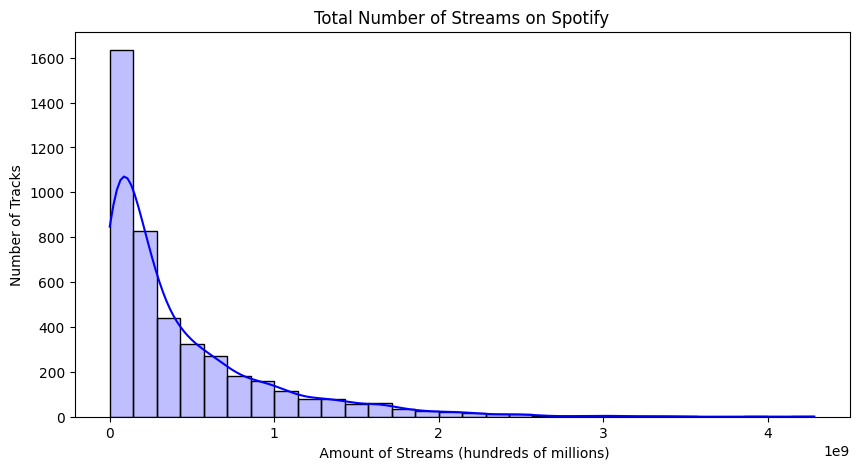

In [446]:
plt.figure(figsize = (10, 5))
sns.histplot(df["spotify_streams"], bins = 30, kde = True, color = "blue", alpha = 0.25)
plt.title("Total Number of Streams on Spotify")
plt.xlabel(" Amount of Streams (hundreds of millions)")
plt.ylabel("Number of Tracks")
plt.show()

### 2. Top 10 Artist on Spotify based on Number of Streams

C:\Users\User\AppData\Local\Temp\ipykernel_24388\2709415920.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_artist.values, y=top_10_artist.index, palette="colorblind")


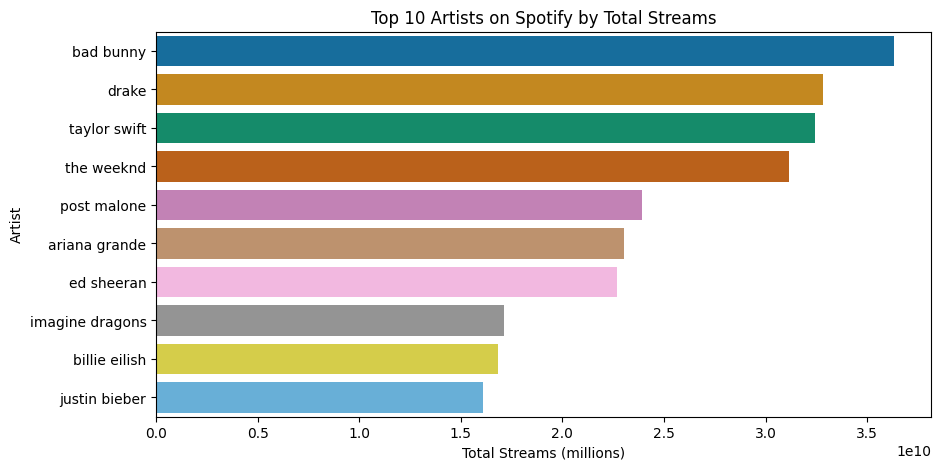

In [447]:
top_10_artist = df.groupby("artist")["spotify_streams"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_artist.values, y=top_10_artist.index, palette="colorblind")
plt.title("Top 10 Artists on Spotify by Total Streams")
plt.xlabel("Total Streams (millions)")
plt.ylabel("Artist")
plt.show()

### 3. Comparison of Streams to Popularity of Spotify

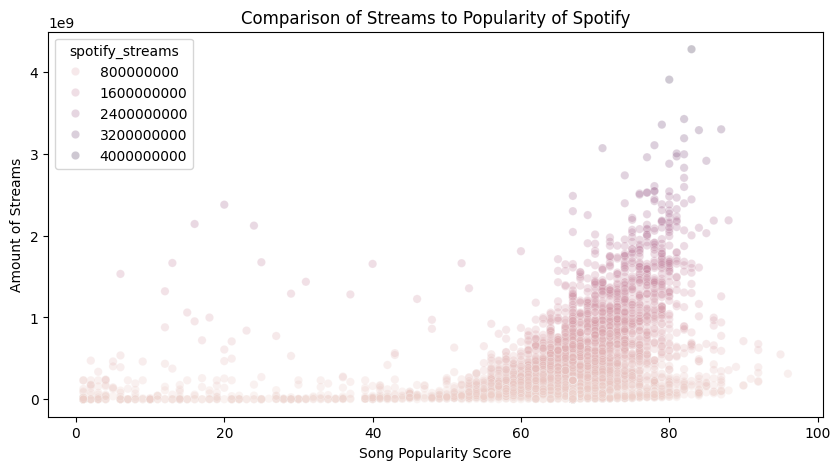

In [448]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='spotify_popularity', y='spotify_streams', data=df, alpha=0.25, hue = "spotify_streams")
plt.title("Comparison of Streams to Popularity of Spotify")
plt.xlabel("Song Popularity Score")
plt.ylabel('Amount of Streams')
plt.show()

## Spotify Content Recommendation System

### 1. Matrix Creation

In [449]:
columns = ["spotify_popularity", "spotify_streams", "spotify_playlist_count", "spotify_playlist_reach", "track_score", "release_year"]

matrix = df[columns].values

In [450]:
column_min = matrix.min(axis=0)
column_max = matrix.max(axis=0)
column_range = np.where(column_max - column_min == 0, 1, column_max - column_min)

matrix_normalisation = (matrix - column_min) / column_range

### 2. Cosine Similarity Matrix

In [451]:
norms = np.linalg.norm(matrix_normalisation, axis=1, keepdims=True)
norms[norms == 0] = 1
matrix_unit = matrix_normalisation / norms
similarity_matrix = matrix_unit @ matrix_unit.T
np.fill_diagonal(similarity_matrix, 0)

### 3. Define Variable Tracks

In [452]:
tracks = df["track"].tolist()

### 4. Create Function for Recommendation System

In [453]:
def recommendations(song_name, number_of_recommended_songs=10):

    if song_name not in tracks:
        print(f"{song_name} not in dataset")
        return pd.DataFrame()
    
    index = tracks.index(song_name)
    value = similarity_matrix[index]
    top_10_similar_tracks = np.argsort(value)[::-1][:number_of_recommended_songs]

    recommended_songs = []

    for song in top_10_similar_tracks:
        songs = df.iloc[song]

        recommended_songs.append({
            "track":              songs["track"],
            "artist":             songs["artist"],
            "spotify_popularity": songs["spotify_popularity"],
            "similarity":         round(float(value[song]), 3)
        })

    return pd.DataFrame(recommended_songs)

### 5. Test the Function "Recommendation"

In [454]:
if __name__ == "__main__":
    for song in ["gata only"]:
        print(f"  Recommendations for: {song}")
        recommendations = recommendations(song)
        if not recommendations.empty:
            print(recommendations.to_string(index=False))

  Recommendations for: gata only
                                   track            artist  spotify_popularity  similarity
                        beautiful things      benson boone                86.0       0.998
                                   lunch     billie eilish                92.0       0.996
we can't be friends (wait for your love)     ariana grande                87.0       0.996
           fortnight (feat. post malone)      taylor swift                89.0       0.996
              band4band (feat. lil baby)       central cee                86.0       0.995
                             lovin on me       jack harlow                83.0       0.994
   i had some help (feat. morgan wallen)       post malone                91.0       0.994
              i like the way you kiss me           artemas                92.0       0.992
                                  greedy        tate mcrae                87.0       0.992
                                espresso sabrina carpente

## Precision Metric

In [455]:
sample_index = np.random.choice(len(tracks), min(4600, len(tracks)), replace=False)

precisions = []

for index in sample_index:
    popularity_index = df.iloc[index]["spotify_popularity"]
    top_10_songs = np.argsort(similarity_matrix[index])[::-1][:10]
    
    total_songs = sum(
        1 for similar_songs in top_10_songs
        if abs(df.iloc[similar_songs]["spotify_popularity"] - popularity_index) <= 10
    )
    precisions.append(total_songs/10)

precision_at_10_accuracy = np.mean(precisions)

print(f"Precision of Content Recommedation System: {precision_at_10_accuracy: }")

Precision of Content Recommedation System:  0.9683161512027493


__Sources used for this precision metric creation__

“https://www.youtube.com/watch?v=3MGYg7pfDSo”

“https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html”

"https://math.stackexchange.com/questions/4286007/how-is-the-precision-matrix-derived-from-the-covariance-matrix"

Aswell as others cited on the PDF on canvas